In [1]:
# -*- coding: utf-8 -*-
"""
Geostatistical Variogram Tutorial in Python for Spatial Data Science
Converted from R notebook by Michael Pyrcz

Original: https://github.com/GeostatsGuy/GeoDataSets
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import rankdata, norm
import warnings
warnings.filterwarnings('ignore')

# For variogram calculation and modeling
# Install: pip install gstools
import gstools as gs

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

print("=" * 70)
print("Geostatistical Variogram Tutorial in Python")
print("=" * 70)

/var/folders/b_/785b5fkd03z7drcwj2yt_rwr0000gp/T/ipykernel_20443/1768767623.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Geostatistical Variogram Tutorial in Python


In [2]:
# URL for the dataset (or download locally)
url = "https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/2D_MV_200Wells.csv"
url = "./data/2D_MV_200Wells.csv"

# Read the data
mydata = pd.read_csv(url)

# Display first few rows
print("First 6 rows of the dataset:")
print(mydata.head())

print("\nColumn names:", mydata.columns.tolist())
print(f"Dataset shape: {mydata.shape}")

First 6 rows of the dataset:
      X     Y  facies_threshold_0.3  porosity  permeability  \
0   565  1485                     1    0.1184         6.170   
1  2585  1185                     1    0.1566         6.275   
2  2065  2865                     2    0.1920        92.297   
3  3575  2655                     1    0.1621         9.048   
4  1835    35                     1    0.1766         7.123   

   acoustic_impedance  
0               2.009  
1               2.864  
2               3.524  
3               2.157  
4               3.979  

Column names: ['X', 'Y', 'facies_threshold_0.3', 'porosity', 'permeability', 'acoustic_impedance']
Dataset shape: (200, 6)


2. Data Preparation - Normal Score Transform
The normal score transform maps data to a standard normal distribution (mean=0, std=1).

In [3]:
def nscore(x):
    """
    Normal score transformation (quantile transformation to standard normal)
    
    Parameters:
    -----------
    x : array-like
        Input data vector
    
    Returns:
    --------
    nscore : array
        Normal scores
    trn_table : DataFrame
        Transformation table for back-transformation
    """
    # Get ranks and handle ties by averaging
    ranks = rankdata(x, method='average')
    
    # Calculate quantiles using Blom's formula (p = (rank - 3/8) / (n + 1/4))
    n = len(x)
    p = (ranks - 3/8) / (n + 1/4)
    
    # Convert to normal scores
    nscore = norm.ppf(p)
    
    # Create transformation table
    trn_table = pd.DataFrame({
        'x': np.sort(x),
        'nscore': np.sort(nscore)
    })
    
    return nscore, trn_table

# Apply normal score transform to porosity
npor_trn, trn_table = nscore(mydata['porosity'].values)
mydata['NPorosity'] = npor_trn

print("\nNormal score transform applied to porosity")
print(f"Original porosity stats: mean={mydata['porosity'].mean():.4f}, std={mydata['porosity'].std():.4f}")
print(f"Normal score stats: mean={mydata['NPorosity'].mean():.4f}, std={mydata['NPorosity'].std():.4f}")

# Display first few rows with the new column
print("\nFirst 6 rows with normal scores:")
print(mydata.head())


Normal score transform applied to porosity
Original porosity stats: mean=0.1493, std=0.0329
Normal score stats: mean=-0.0000, std=0.9937

First 6 rows with normal scores:
      X     Y  facies_threshold_0.3  porosity  permeability  \
0   565  1485                     1    0.1184         6.170   
1  2585  1185                     1    0.1566         6.275   
2  2065  2865                     2    0.1920        92.297   
3  3575  2655                     1    0.1621         9.048   
4  1835    35                     1    0.1766         7.123   

   acoustic_impedance  NPorosity  
0               2.009  -0.982522  
1               2.864   0.169799  
2               3.524   1.385033  
3               2.157   0.364673  
4               3.979   0.729546  


3. Visualize Original and Transformed Distributions

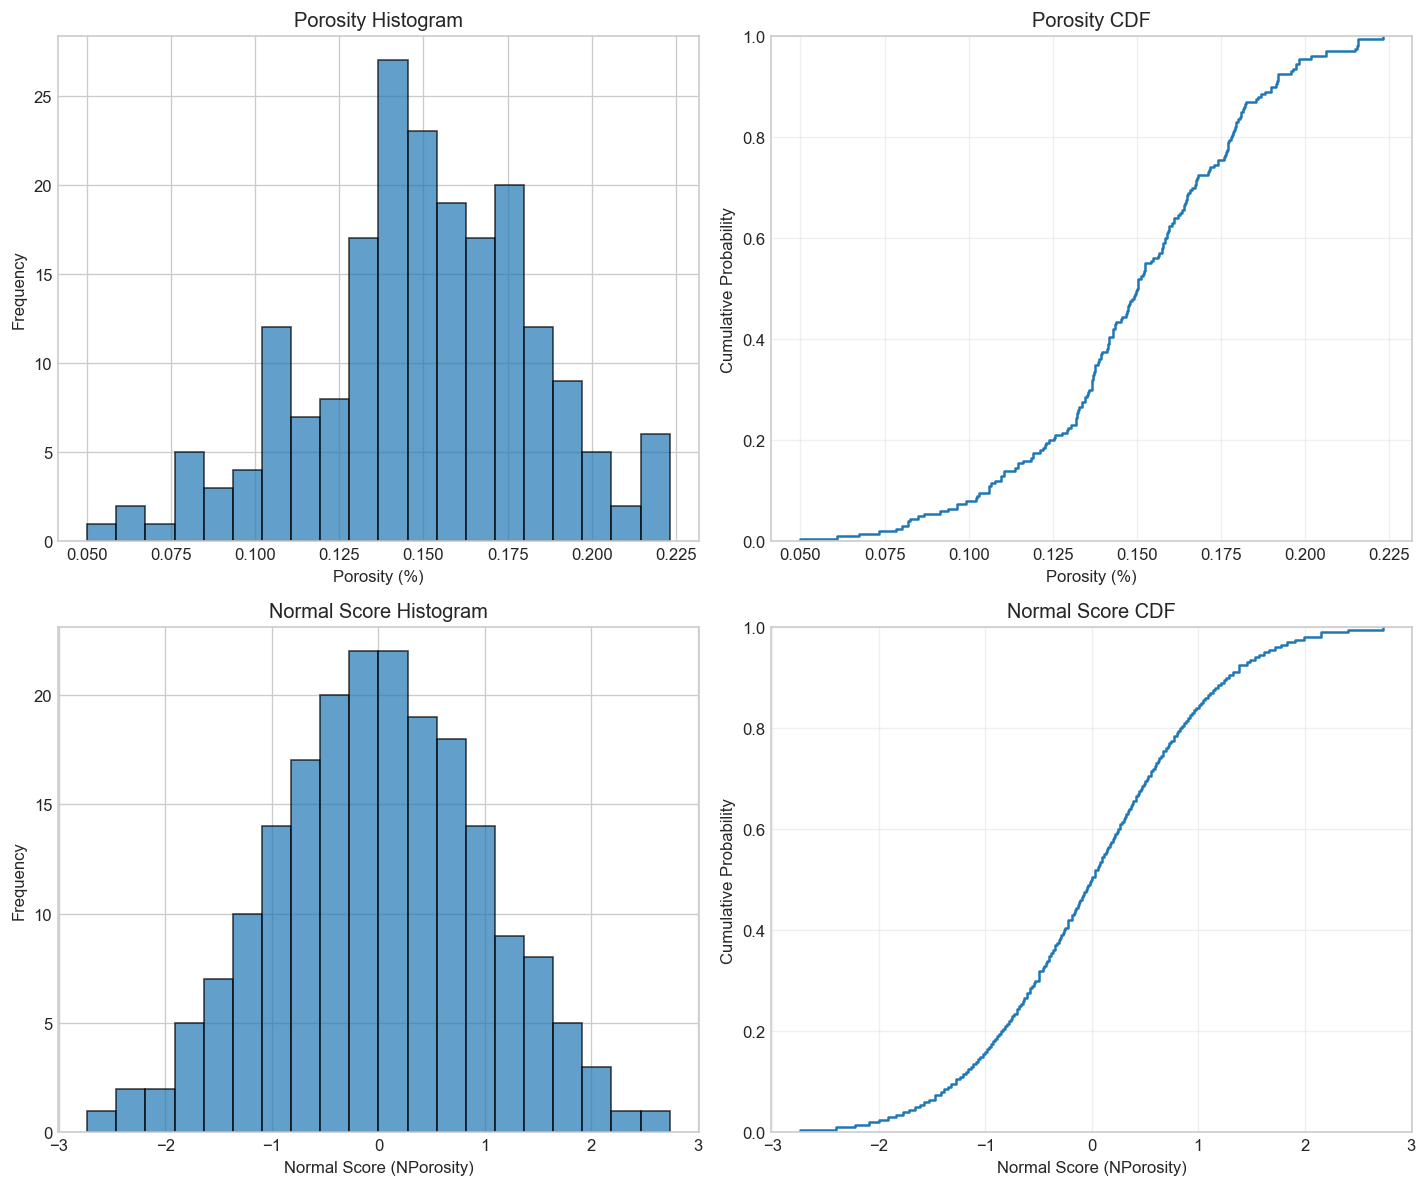

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original porosity histogram
axes[0, 0].hist(mydata['porosity'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Porosity (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Porosity Histogram')

# Original porosity CDF (empirical)
axes[0, 1].ecdf(mydata['porosity'])
axes[0, 1].set_xlabel('Porosity (%)')
axes[0, 1].set_ylabel('Cumulative Probability')
axes[0, 1].set_title('Porosity CDF')
axes[0, 1].grid(True, alpha=0.3)

# Normal score histogram
axes[1, 0].hist(mydata['NPorosity'], bins=20, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Normal Score (NPorosity)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Normal Score Histogram')

# Normal score CDF
axes[1, 1].ecdf(mydata['NPorosity'])
axes[1, 1].set_xlabel('Normal Score (NPorosity)')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Normal Score CDF')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('porosity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

4. Spatial Visualization

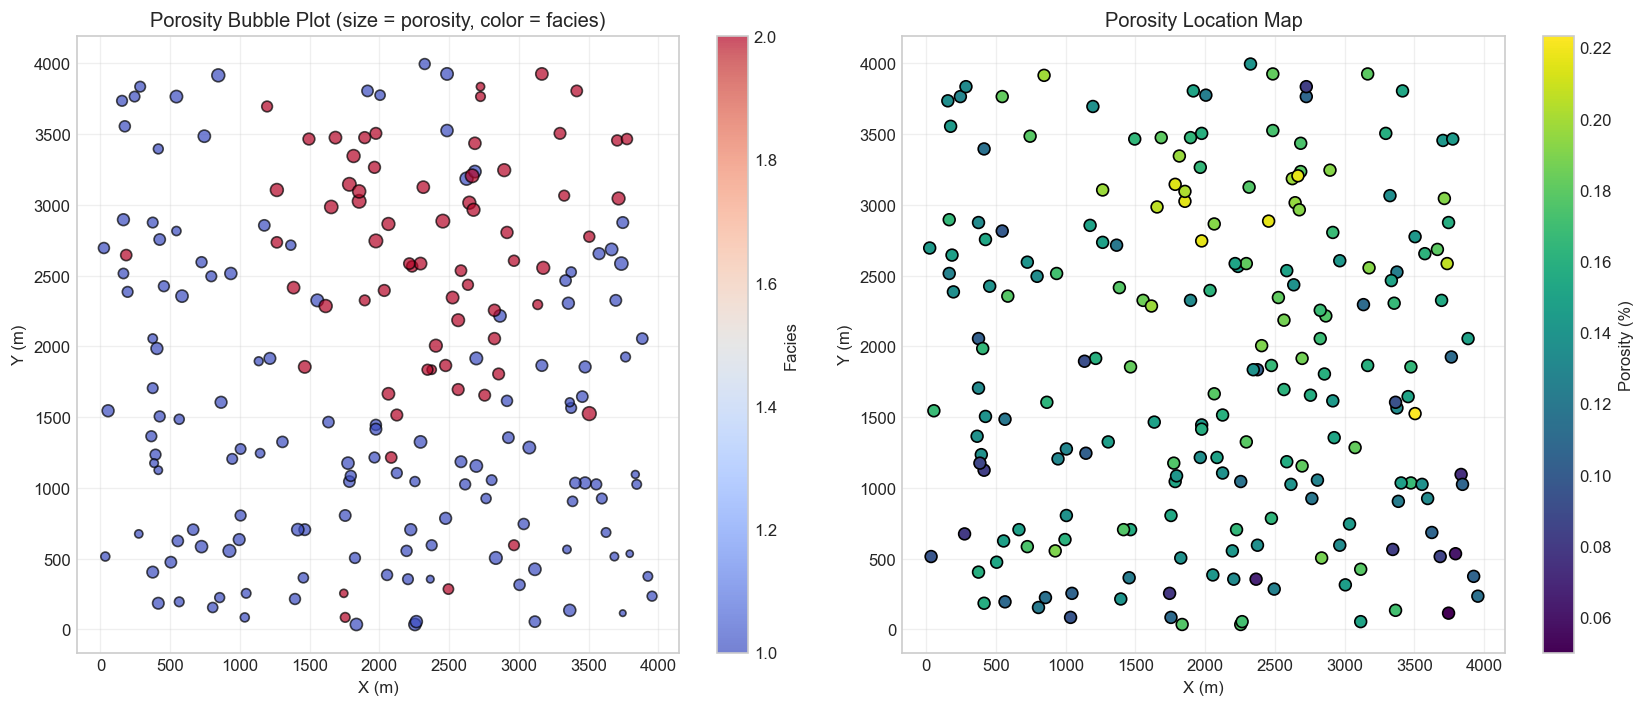

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bubble plot (size = porosity, color = facies)
scatter1 = axes[0].scatter(mydata['X'], mydata['Y'], 
                           s=mydata['porosity'] * 300,  # scale for visibility
                           c=mydata['facies_threshold_0.3'], 
                           cmap='coolwarm', alpha=0.7, edgecolors='black')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].set_title('Porosity Bubble Plot (size = porosity, color = facies)')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Facies')

# Location map with porosity colors
scatter2 = axes[1].scatter(mydata['X'], mydata['Y'], 
                           c=mydata['porosity'], 
                           cmap='viridis', s=50, edgecolors='black')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].set_title('Porosity Location Map')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Porosity (%)')

plt.tight_layout()
plt.savefig('spatial_maps.png', dpi=150, bbox_inches='tight')
plt.show()

5. Isotropic Variogram Calculation


Isotropic variogram calculated:
Number of lags: 7
Lag distances: [ 214.28571429  642.85714286 1071.42857143 1500.         1928.57142857]...
Gamma values: [0.62399939 0.77018743 0.81758694 0.89672211 0.99070677]...


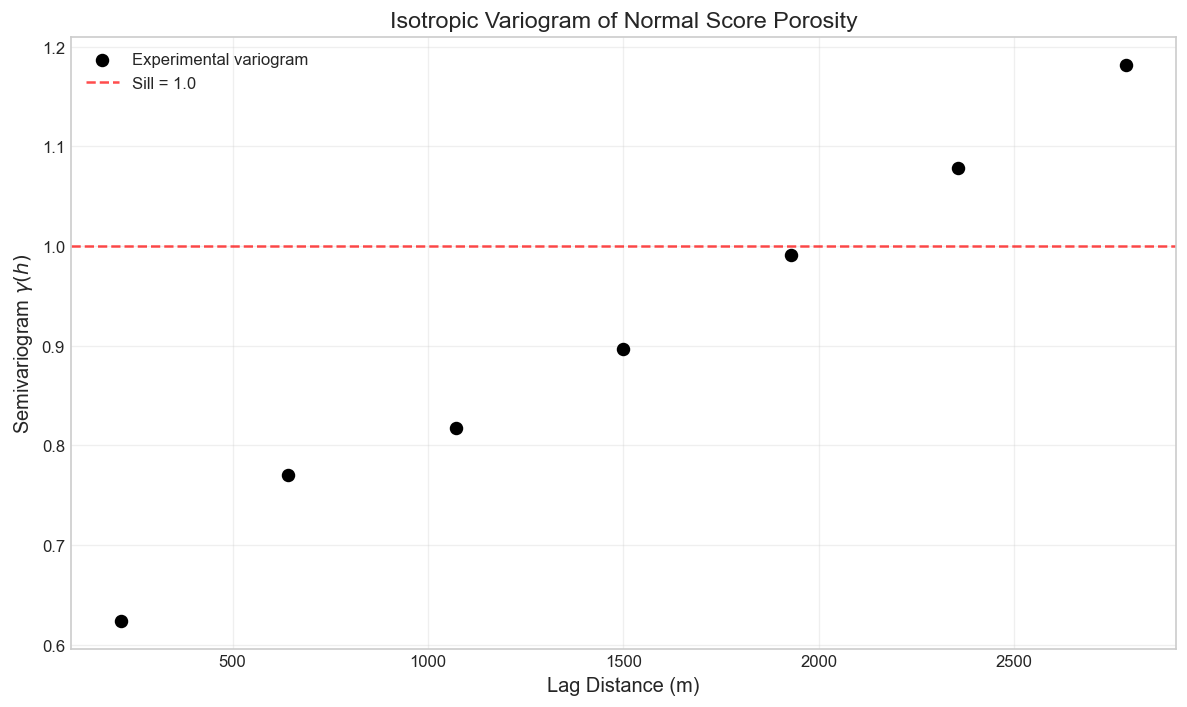

In [5]:
import gstools as gs

# Extract coordinates and values
coords = mydata[['X', 'Y']].values.T  # Transpose to (dim, n_points) = (2, 200)
values = mydata['NPorosity'].values

# Define binning parameters
max_dist = 3000  # maximum lag distance (m)
bin_width = 400  # bin width (m)

# Number of bins
n_bins = int(max_dist / bin_width)
bin_edges = np.linspace(0, max_dist, n_bins + 1)

# Calculate empirical variogram using gs.vario_estimate
lags, gamma = gs.vario_estimate(
    coords,              # transposed to (2, 200)
    values,
    bin_edges=bin_edges,
    direction=None,      # None gives omnidirectional variogram
    return_counts=False
)

print("Isotropic variogram calculated:")
print(f"Number of lags: {len(lags)}")
print(f"Lag distances: {lags[:5]}...")
print(f"Gamma values: {gamma[:5]}...")

# Plot the isotropic variogram
fig, ax = plt.subplots(figsize=(10, 6))

# Plot experimental variogram points
ax.scatter(lags, gamma, c='black', s=50, zorder=5, label='Experimental variogram')

# Add horizontal line at sill (should be 1.0 for normal scores)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Sill = 1.0')

ax.set_xlabel('Lag Distance (m)', fontsize=12)
ax.set_ylabel('Semivariogram $\gamma(h)$', fontsize=12)
ax.set_title('Isotropic Variogram of Normal Score Porosity', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('isotropic_variogram.png', dpi=150, bbox_inches='tight')
plt.show()

6. Fit an Isotropic Variogram Model
Now we fit a theoretical variogram model to the experimental variogram.

Spherical model fit:
  Nugget: 0.540
  Sill: 0.454
  Range: 2000.0 m
  Total sill (nugget + sill): 0.994


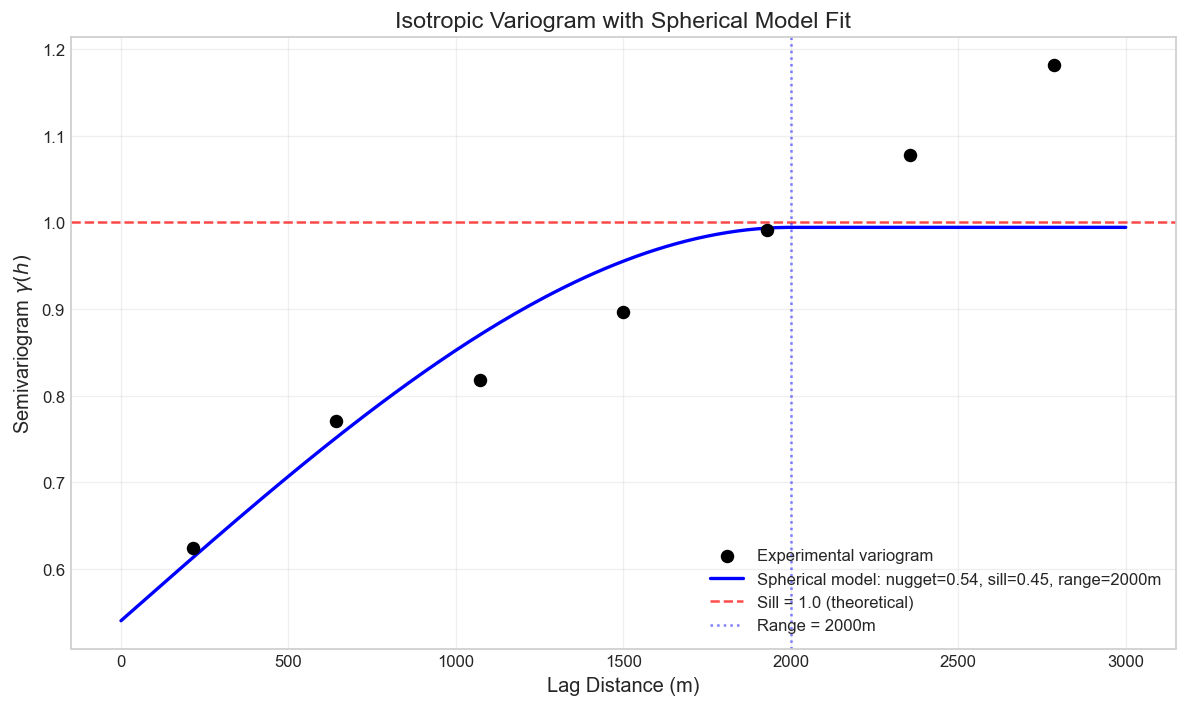

In [6]:
from scipy.optimize import curve_fit
from scipy.spatial.distance import cdist

def spherical_model(h, nugget, sill, range_):
    """
    Spherical variogram model
    """
    gamma = np.zeros_like(h, dtype=float)
    mask = h <= range_
    gamma[mask] = nugget + sill * (1.5 * (h[mask]/range_) - 0.5 * (h[mask]/range_)**3)
    gamma[~mask] = nugget + sill
    return gamma

def exponential_model(h, nugget, sill, range_):
    """
    Exponential variogram model (effective range = 3 * range_)
    """
    return nugget + sill * (1 - np.exp(-3 * h / range_))

def gaussian_model(h, nugget, sill, range_):
    """
    Gaussian variogram model (effective range = sqrt(3) * range_)
    """
    return nugget + sill * (1 - np.exp(-3 * (h / range_)**2))

# Fit spherical model to the experimental variogram
# Ignore zero lag (gamma[0] = 0) and potentially noisy points at large lags
valid_mask = (lags > 0) & (lags < 2500)

try:
    # Initial parameter guesses: nugget=0.4, sill=0.6, range=800
    params, _ = curve_fit(
        spherical_model, 
        lags[valid_mask], 
        gamma[valid_mask],
        p0=[0.4, 0.6, 800],
        bounds=([0, 0, 100], [1, 1, 2000])
    )
    nugget_fit, sill_fit, range_fit = params
    print(f"Spherical model fit:")
    print(f"  Nugget: {nugget_fit:.3f}")
    print(f"  Sill: {sill_fit:.3f}")
    print(f"  Range: {range_fit:.1f} m")
    print(f"  Total sill (nugget + sill): {nugget_fit + sill_fit:.3f}")
    
except Exception as e:
    print(f"Curve fitting failed: {e}")
    print("Using manual fit parameters")
    nugget_fit, sill_fit, range_fit = 0.4, 0.6, 800

# Generate model values for plotting
h_smooth = np.linspace(0, max_dist, 200)
gamma_model = spherical_model(h_smooth, nugget_fit, sill_fit, range_fit)

# Plot experimental and modeled variogram
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(lags, gamma, c='black', s=50, zorder=5, label='Experimental variogram')
ax.plot(h_smooth, gamma_model, 'b-', linewidth=2, label=f'Spherical model: nugget={nugget_fit:.2f}, sill={sill_fit:.2f}, range={range_fit:.0f}m')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Sill = 1.0 (theoretical)')
ax.axvline(x=range_fit, color='blue', linestyle=':', alpha=0.5, label=f'Range = {range_fit:.0f}m')

ax.set_xlabel('Lag Distance (m)', fontsize=12)
ax.set_ylabel('Semivariogram $\gamma(h)$', fontsize=12)
ax.set_title('Isotropic Variogram with Spherical Model Fit', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('isotropic_variogram_model.png', dpi=150, bbox_inches='tight')
plt.show()

7. Variogram Map for Anisotropy Detection


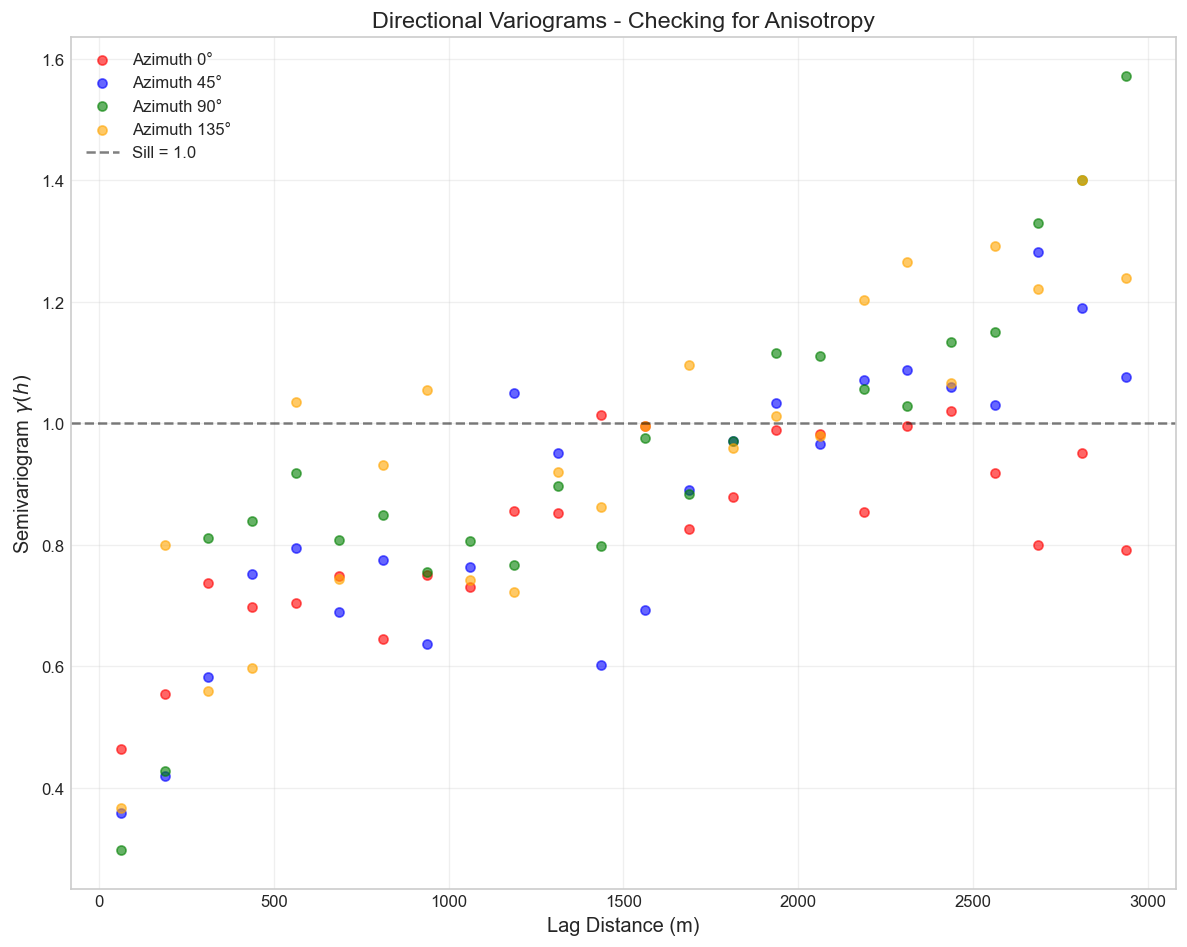

Observing the directional variograms can reveal anisotropy.
If ranges differ by direction, the phenomenon is geometrically anisotropic.


In [7]:
import gstools as gs
import numpy as np

# Ensure coordinates are transposed to (dim, n_points)
coords = mydata[['X', 'Y']].values.T  # Shape: (2, 200)
values = mydata['NPorosity'].values

# Define bin edges
max_dist = 3000
n_bins = 24
bin_edges = np.linspace(0, max_dist, n_bins + 1)

# Compute directional variograms at different azimuths (in radians)
# Convert azimuth angles from degrees to radians
azimuths_deg = [0, 45, 90, 135]
azimuths_rad = np.deg2rad(azimuths_deg)  # Convert to radians for gstools
colors = ['red', 'blue', 'green', 'orange']
bandwidth_deg = 22.5
angles_tol_rad = np.deg2rad(bandwidth_deg)  # Convert tolerance to radians

fig, ax = plt.subplots(figsize=(10, 8))

# For each azimuth, compute directional variogram using 'angles' parameter
for az_rad, az_deg, color in zip(azimuths_rad, azimuths_deg, colors):
    # Use 'angles' parameter with radians (counter-clockwise from +x axis)
    lags_dir, gamma_dir = gs.vario_estimate(
        coords,              # transposed coordinates (2, n_points)
        values,
        bin_edges=bin_edges,
        angles=az_rad,       # azimuth in radians (CCW from +x)
        angles_tol=angles_tol_rad,  # tolerance in radians
        return_counts=False
    )
    
    # Plot
    ax.scatter(lags_dir, gamma_dir, c=color, s=30, alpha=0.6, label=f'Azimuth {az_deg}°')

# Add reference line
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Sill = 1.0')

ax.set_xlabel('Lag Distance (m)', fontsize=12)
ax.set_ylabel('Semivariogram $\gamma(h)$', fontsize=12)
ax.set_title('Directional Variograms - Checking for Anisotropy', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('directional_variograms.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observing the directional variograms can reveal anisotropy.")
print("If ranges differ by direction, the phenomenon is geometrically anisotropic.")

:question: **What does the nugget in the fitted model represent?**

:question: **Fit spherical variograms separately to azimuth 0 and 90 degree empirical variograms, and comment if isotropy was a suitable assumption.**